# 04 - Explicabilidad, análisis de errores y métricas de negocio

## Predicción del riesgo de rotura de stock en un entorno logístico

Este notebook completa el Proyecto 1 mediante cuatro bloques:

1. **Evaluación final del modelo seleccionado** sobre el conjunto de test temporal.
2. **Explicabilidad global e individual**, para comprender qué variables sostienen las predicciones.
3. **Traducción a decisiones de negocio**, mediante umbrales, priorización y escenarios económicos simulados.
4. **Propuesta conceptual de producción**, monitorización, reentrenamiento y control de drift.

> **Limitación esencial:** el target `stockout_risk` es una aproximación sintética construida a partir de demanda histórica, demanda futura simulada y variables logísticas aproximadas. No representa una rotura real observada en un WMS. Por ello, los resultados económicos son simulaciones y no ahorros reales certificados.

## 1. Importación de librerías y configuración

Utilizon rutas reproducibles, métricas de clasificación, explicabilidad por permutación y, cuando está disponible, SHAP.

### ¿Por qué calculo la importancia por permutación?

Cambio de forma controlada los valores de cada variable y observo cuánto empeora el rendimiento del modelo.

Si el resultado empeora mucho, considero que esa variable aporta información importante.

Uso esta técnica como complemento porque funciona con distintos tipos de modelos y no depende únicamente de la importancia interna del algoritmo.


In [1]:
# En esta celda desarrollo el paso explicado justo arriba.
from pathlib import Path
import json
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve,
    roc_curve,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
RANDOM_STATE = 42

## 2. Resolución de rutas y validación de artefactos

### ¿Qué quiero conseguir con este análisis?

En este bloque reviso el comportamiento del modelo desde un punto de vista más práctico.

No me interesa únicamente saber si el modelo acierta, sino entender en qué casos falla, qué variables influyen y cómo podrían utilizarse las predicciones para tomar decisiones.

Una alternativa sería limitarme a mostrar las métricas generales, pero eso no sería suficiente para explicar el valor del modelo ni sus limitaciones.


In [2]:
# En esta celda desarrollo el paso explicado justo arriba.
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "data").exists() and (candidate / "models").exists():
            return candidate
    return start.parent if start.name == "notebooks" else start

PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "stockout_dataset.csv"
MODEL_PATH = PROJECT_ROOT / "models" / "best_stockout_model.pkl"
FEATURES_PATH = PROJECT_ROOT / "models" / "model_features.json"
MODEL_METADATA_PATH = PROJECT_ROOT / "models" / "model_metadata.json"

PREDICTION_CANDIDATES = [
    PROJECT_ROOT / "outputs" / "predictions" / "test_predictions_best_model.csv",
    PROJECT_ROOT / "outputs" / "test_predictions_best_model.csv",
]
PREDICTIONS_PATH = next((p for p in PREDICTION_CANDIDATES if p.exists()), PREDICTION_CANDIDATES[0])

OUTPUT_METRICS_DIR = PROJECT_ROOT / "outputs" / "metrics"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures" / "explainability_business"
OUTPUT_REPORTS_DIR = PROJECT_ROOT / "outputs" / "reports"

for folder in [OUTPUT_METRICS_DIR, OUTPUT_FIGURES_DIR, OUTPUT_REPORTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

required_files = [DATA_PATH, MODEL_PATH, FEATURES_PATH, PREDICTIONS_PATH]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "Faltan artefactos del notebook 03. Ejecuta los notebooks 01, 02 y 03 en orden.\n"
        + "\n".join(missing_files)
    )

print("Raíz del proyecto:", PROJECT_ROOT)
print("Predicciones:", PREDICTIONS_PATH)

Raíz del proyecto: C:\Users\lloro\Documents\GitHub\TFE_PROYECTO1
Predicciones: C:\Users\lloro\Documents\GitHub\TFE_PROYECTO1\outputs\predictions\test_predictions_best_model.csv


## 3. Carga del modelo, metadatos, dataset y predicciones

### ¿Por qué utilizo SHAP?

Utilizo SHAP para entender cómo influye cada variable en las predicciones del modelo.

Esta técnica me permite analizar la importancia global de las variables y también revisar casos concretos.

Podría utilizar únicamente la importancia interna del modelo, pero SHAP aporta una explicación más completa sobre el sentido y la intensidad de cada efecto.


In [3]:
# En esta celda desarrollo el paso explicado justo arriba.
model = joblib.load(MODEL_PATH)

with open(FEATURES_PATH, "r", encoding="utf-8") as file:
    model_features = json.load(file)

model_metadata = {}
if MODEL_METADATA_PATH.exists():
    with open(MODEL_METADATA_PATH, "r", encoding="utf-8") as file:
        model_metadata = json.load(file)

df = pd.read_csv(DATA_PATH, parse_dates=["date"])
predictions = pd.read_csv(PREDICTIONS_PATH)

print("Modelo:", type(model).__name__)
print("Features:", len(model_features))
print("Dataset procesado:", df.shape)
print("Predicciones test:", predictions.shape)
display(predictions.head())

Modelo: XGBClassifier
Features: 39
Dataset procesado: (4472500, 56)
Predicciones test: (895000, 13)


,date,store_id,item_id,future_demand_lead_time,stock_estimated,safety_stock,coverage_days,lead_time_days,y_true,y_pred_threshold_050,y_proba,model,dataset_split
0,2023-01-01,store_1,item_1,107.0000,44.5000,25.0452,1,2,1,1,0.5898,XGBoost,test
1,2023-01-01,store_1,item_10,139.0000,177.0667,23.2916,8,5,0,1,0.7308,XGBoost,test
2,2023-01-01,store_1,item_11,53.0000,94.8000,12.0717,4,2,0,0,0.1818,XGBoost,test
3,2023-01-01,store_1,item_12,123.0000,20.9333,20.3966,1,4,1,1,0.6410,XGBoost,test
4,2023-01-01,store_1,item_13,140.0000,317.6000,21.6808,8,3,0,0,0.3969,XGBoost,test


## 4. Normalización y validación del archivo de predicciones

El notebook 03 es la fuente de verdad del conjunto de test. No se reconstruye aquí mediante otro percentil porque eso podría producir una muestra diferente.

### ¿Qué quiero conseguir con este análisis?

En este bloque reviso el comportamiento del modelo desde un punto de vista más práctico.

No me interesa únicamente saber si el modelo acierta, sino entender en qué casos falla, qué variables influyen y cómo podrían utilizarse las predicciones para tomar decisiones.

Una alternativa sería limitarme a mostrar las métricas generales, pero eso no sería suficiente para explicar el valor del modelo ni sus limitaciones.


In [4]:
# En esta celda desarrollo el paso explicado justo arriba.
rename_candidates = {
    "y_true": ["stockout_risk", "target", "actual", "real"],
    "y_pred": ["prediction", "predicted", "pred"],
    "y_proba": ["probability", "proba", "predicted_probability", "risk_probability"],
}

for canonical, alternatives in rename_candidates.items():
    if canonical not in predictions.columns:
        match = next((col for col in alternatives if col in predictions.columns), None)
        if match:
            predictions = predictions.rename(columns={match: canonical})

required_prediction_columns = {"y_true", "y_proba"}
missing = required_prediction_columns - set(predictions.columns)
if missing:
    raise ValueError(f"Faltan columnas obligatorias en las predicciones: {sorted(missing)}")

predictions["y_true"] = pd.to_numeric(predictions["y_true"], errors="raise").astype(int)
predictions["y_proba"] = pd.to_numeric(predictions["y_proba"], errors="raise")

if not predictions["y_proba"].between(0, 1).all():
    raise ValueError("`y_proba` contiene valores fuera del intervalo [0, 1].")

if "y_pred" not in predictions.columns:
    predictions["y_pred"] = (predictions["y_proba"] >= 0.50).astype(int)
else:
    predictions["y_pred"] = pd.to_numeric(predictions["y_pred"], errors="raise").astype(int)

if "date" in predictions.columns:
    predictions["date"] = pd.to_datetime(predictions["date"], errors="coerce")

if predictions["y_true"].nunique() < 2:
    raise ValueError("El conjunto de test solo contiene una clase; no permite una evaluación válida.")

print(predictions[["y_true", "y_pred", "y_proba"]].describe())

            y_true       y_pred      y_proba
count 895,000.0000 895,000.0000 895,000.0000
mean        0.5339       0.5012       0.5127
std         0.4989       0.5000       0.2995
min         0.0000       0.0000       0.0130
25%         0.0000       0.0000       0.2430
50%         1.0000       1.0000       0.5012
75%         1.0000       1.0000       0.7935
max         1.0000       1.0000       0.9980


## 5. Métricas técnicas finales con umbral 0,50

### ¿Por qué reviso la matriz de confusión?

La matriz de confusión me permite ver los aciertos y los errores en valores absolutos.

Me fijo especialmente en los falsos negativos, porque representan casos de riesgo que el modelo no detecta, y en los falsos positivos, porque generan revisiones innecesarias.

Las métricas resumen el rendimiento, pero esta matriz ayuda a interpretar mejor qué está ocurriendo.


In [5]:
# En esta celda desarrollo el paso explicado justo arriba.
y_true = predictions["y_true"].to_numpy()
y_proba = predictions["y_proba"].to_numpy()
y_pred_050 = (y_proba >= 0.50).astype(int)

tn, fp, fn, tp = confusion_matrix(y_true, y_pred_050, labels=[0, 1]).ravel()

final_metrics = {
    "threshold": 0.50,
    "accuracy": accuracy_score(y_true, y_pred_050),
    "precision": precision_score(y_true, y_pred_050, zero_division=0),
    "recall": recall_score(y_true, y_pred_050, zero_division=0),
    "f1_score": f1_score(y_true, y_pred_050, zero_division=0),
    "roc_auc": roc_auc_score(y_true, y_proba),
    "pr_auc": average_precision_score(y_true, y_proba),
    "tn": int(tn),
    "fp": int(fp),
    "fn": int(fn),
    "tp": int(tp),
    "alerts_generated": int(tp + fp),
    "alert_rate": float((tp + fp) / len(y_true)),
}

final_metrics_df = pd.DataFrame([final_metrics])
final_metrics_df.to_csv(OUTPUT_METRICS_DIR / "final_model_metrics.csv", index=False)
display(final_metrics_df)
print(classification_report(y_true, y_pred_050, zero_division=0))

,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,tn,fp,fn,tp,alerts_generated,alert_rate
0,0.5000,0.7937,0.8267,0.7761,0.8006,0.8843,0.8990,339479,77718,106959,370844,448562,0.5012


              precision    recall  f1-score   support

           0       0.76      0.81      0.79    417197
           1       0.83      0.78      0.80    477803

    accuracy                           0.79    895000
   macro avg       0.79      0.79      0.79    895000
weighted avg       0.80      0.79      0.79    895000



### ¿Por qué reviso la matriz de confusión?

La matriz de confusión me permite ver los aciertos y los errores en valores absolutos.

Me fijo especialmente en los falsos negativos, porque representan casos de riesgo que el modelo no detecta, y en los falsos positivos, porque generan revisiones innecesarias.

Las métricas resumen el rendimiento, pero esta matriz ayuda a interpretar mejor qué está ocurriendo.


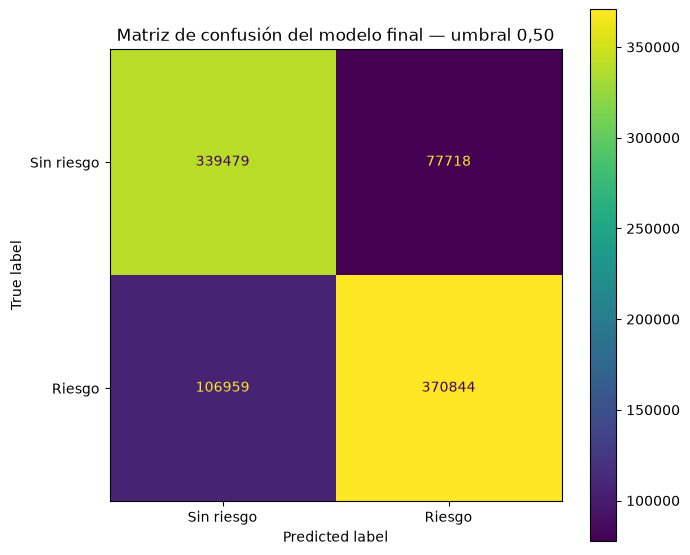

In [6]:
# En esta celda desarrollo el paso explicado justo arriba.
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(
    confusion_matrix=np.array([[tn, fp], [fn, tp]]),
    display_labels=["Sin riesgo", "Riesgo"],
).plot(ax=ax, values_format="d")
ax.set_title("Matriz de confusión del modelo final — umbral 0,50")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "confusion_matrix_threshold_050.png", dpi=160, bbox_inches="tight")
plt.show()

### ¿Por qué represento estas curvas?

Las curvas ROC y Precision-Recall me permiten observar cómo cambia el rendimiento al modificar el umbral.

La curva ROC muestra la relación entre verdaderos positivos y falsos positivos. La curva Precision-Recall se centra más en la calidad de las alertas positivas.

Mantengo ambas porque ofrecen puntos de vista diferentes y complementarios.


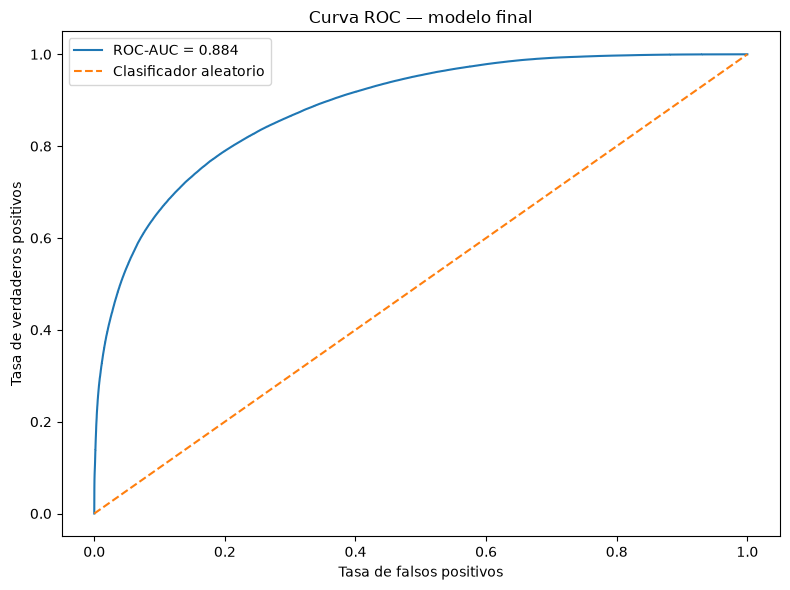

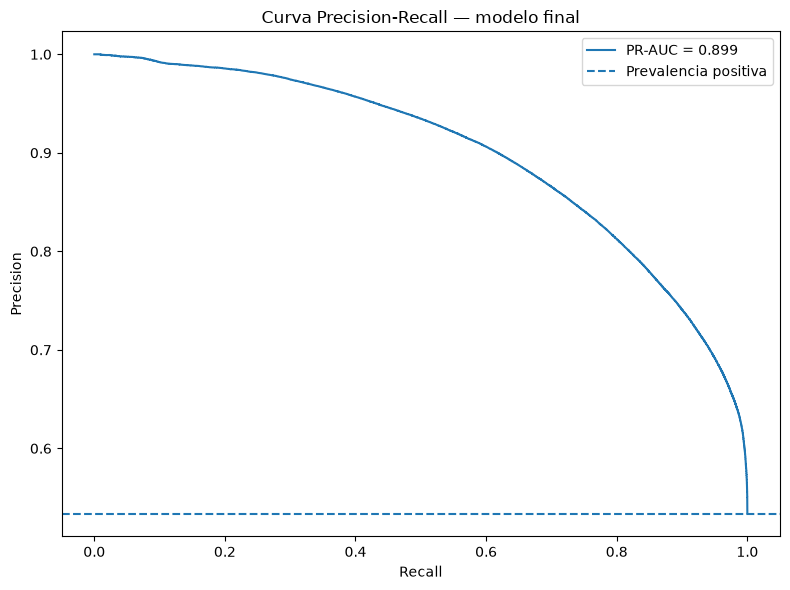

In [7]:
# En esta celda desarrollo el paso explicado justo arriba.
fpr, tpr, _ = roc_curve(y_true, y_proba)
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {final_metrics['roc_auc']:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Clasificador aleatorio")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title("Curva ROC — modelo final")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "final_roc_curve.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {final_metrics['pr_auc']:.3f}")
plt.axhline(y=np.mean(y_true), linestyle="--", label="Prevalencia positiva")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall — modelo final")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "final_precision_recall_curve.png", dpi=160, bbox_inches="tight")
plt.show()

## 6. Reconstrucción exacta de `X_test`

Se priorizan las features ya incluidas en el archivo de predicciones. Si no están, se recuperan del dataset mediante claves (`date`, `store_id`, `item_id`). Esto evita volver a calcular un corte temporal diferente.

### ¿Por qué utilizo SHAP?

Utilizo SHAP para entender cómo influye cada variable en las predicciones del modelo.

Esta técnica me permite analizar la importancia global de las variables y también revisar casos concretos.

Podría utilizar únicamente la importancia interna del modelo, pero SHAP aporta una explicación más completa sobre el sentido y la intensidad de cada efecto.


In [9]:
# Compruebo qué variables del modelo ya están disponibles en el archivo de predicciones.
features_in_predictions = [
    feature
    for feature in model_features
    if feature in predictions.columns
]

# Identifico únicamente las variables que necesito recuperar del dataset procesado.
missing_features = [
    feature
    for feature in model_features
    if feature not in predictions.columns
]

print(f"Features ya disponibles en predictions: {len(features_in_predictions)}")
print(f"Features que necesito recuperar: {len(missing_features)}")

# Empiezo con una copia para no modificar el DataFrame original de predicciones.
enriched = predictions.copy()

if missing_features:
    join_keys = [
        key
        for key in ["date", "store_id", "item_id"]
        if key in predictions.columns and key in df.columns
    ]

    if not join_keys:
        raise ValueError(
            "No es posible reconstruir X_test porque las predicciones "
            "no contienen claves comunes con el dataset procesado."
        )

    # Compruebo que las features pendientes existan en el dataset procesado.
    unavailable_features = [
        feature
        for feature in missing_features
        if feature not in df.columns
    ]

    if unavailable_features:
        raise ValueError(
            "El dataset procesado no contiene estas features: "
            f"{unavailable_features}"
        )

    duplicated_lookup = df.duplicated(join_keys).sum()

    if duplicated_lookup:
        raise ValueError(
            f"El dataset tiene {duplicated_lookup} duplicados "
            f"para las claves {join_keys}."
        )

    # Solo incorporo las features que todavía no existen en predictions.
    lookup_columns = join_keys + missing_features

    enriched = predictions.merge(
        df[lookup_columns],
        on=join_keys,
        how="left",
        validate="many_to_one"
    )

# Verifico que después del proceso estén disponibles todas las features.
still_missing = [
    feature
    for feature in model_features
    if feature not in enriched.columns
]

if still_missing:
    raise ValueError(
        "No se pudieron recuperar estas features: "
        f"{still_missing}"
    )

# Compruebo si alguna predicción no encontró correspondencia en el dataset.
rows_with_missing_features = enriched[model_features].isna().any(axis=1)

if rows_with_missing_features.any():
    missing_rows = int(rows_with_missing_features.sum())

    raise ValueError(
        f"No se pudieron recuperar todas las features para "
        f"{missing_rows} predicciones."
    )

# Construyo el conjunto de test que utilizaré para la explicabilidad.
X_test = enriched[model_features].copy()

print("X_test reconstruido:", X_test.shape)

Features ya disponibles en predictions: 1
Features que necesito recuperar: 38
X_test reconstruido: (895000, 39)


## 7. Explicabilidad global

Utilizo una estrategia escalonada:

1. Importancia nativa del estimador cuando existe.
2. Importancia por permutación, válida también para pipelines.
3. SHAP, cuando la librería y el tipo de modelo lo permiten.

La importancia no implica causalidad. Solo describe cuánto depende el modelo de cada variable en esta muestra.

### ¿Qué quiero conseguir con este análisis?

En este bloque reviso el comportamiento del modelo desde un punto de vista más práctico.

No me interesa únicamente saber si el modelo acierta, sino entender en qué casos falla, qué variables influyen y cómo podrían utilizarse las predicciones para tomar decisiones.

Una alternativa sería limitarme a mostrar las métricas generales, pero eso no sería suficiente para explicar el valor del modelo ni sus limitaciones.


In [10]:
# En esta celda desarrollo el paso explicado justo arriba.
def get_final_estimator(fitted_model):
    if hasattr(fitted_model, "named_steps"):
        return list(fitted_model.named_steps.values())[-1]
    return fitted_model

estimator = get_final_estimator(model)
native_importance = None
importance_type = None

if hasattr(estimator, "feature_importances_"):
    native_importance = np.asarray(estimator.feature_importances_)
    importance_type = "feature_importances"
elif hasattr(estimator, "coef_"):
    coef = np.asarray(estimator.coef_)
    native_importance = np.abs(coef[0] if coef.ndim > 1 else coef)
    importance_type = "absolute_coefficient"

if native_importance is not None and len(native_importance) == len(model_features):
    native_importance_df = (
        pd.DataFrame({"feature": model_features, "importance": native_importance})
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )
    native_importance_df["importance_type"] = importance_type
    native_importance_df.to_csv(OUTPUT_METRICS_DIR / "native_feature_importance.csv", index=False)
    display(native_importance_df.head(15))
else:
    native_importance_df = pd.DataFrame()
    print("El modelo no expone una importancia nativa directamente comparable.")

,feature,importance,importance_type
0,lead_time_days,0.4271,feature_importances
1,sales_lag_14,0.0616,feature_importances
2,week_cos,0.0431,feature_importances
3,price,0.0407,feature_importances
4,weekday_cos,0.0325,feature_importances
5,rolling_price_mean_30,0.0312,feature_importances
6,sales_lag_1,0.0303,feature_importances
7,weekday_sin,0.0287,feature_importances
8,sales_lag_7,0.0251,feature_importances
9,rolling_mean_30,0.0243,feature_importances


### ¿Por qué calculo la importancia por permutación?

Cambio de forma controlada los valores de cada variable y observo cuánto empeora el rendimiento del modelo.

Si el resultado empeora mucho, considero que esa variable aporta información importante.

Uso esta técnica como complemento porque funciona con distintos tipos de modelos y no depende únicamente de la importancia interna del algoritmo.


In [ ]:
# Para evitar problemas de memoria, utilizo una muestra más pequeña
# y ejecuto el cálculo con un solo núcleo.

sample_n = min(2000, len(X_test))

X_perm = X_test.sample(
    n=sample_n,
    random_state=RANDOM_STATE
)

y_perm = y_true[X_perm.index]

permutation_result = permutation_importance(
    model,
    X_perm,
    y_perm,
    scoring="average_precision",
    n_repeats=3,
    random_state=RANDOM_STATE,
    n_jobs=1
)

permutation_importance_df = pd.DataFrame({
    "feature": model_features,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std
})

permutation_importance_df = (
    permutation_importance_df
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

permutation_importance_df.to_csv(
    OUTPUT_METRICS_DIR / "permutation_feature_importance.csv",
    index=False
)

display(permutation_importance_df.head(15))

,feature,importance_mean,importance_std
0,lead_time_days,0.3289,0.0123
1,price,0.0414,0.0011
2,rolling_price_mean_30,0.0163,0.0018
3,price_vs_mean_30,0.0135,0.0005
4,price_ratio_mean_30,0.0115,0.0012
5,rolling_mean_30,0.0062,0.0008
6,week_cos,0.0062,0.0021
7,demand_cv_30,0.0029,0.0003
8,weekday_cos,0.0023,0.0005
9,weekday_sin,0.0012,0.0003


### ¿Por qué calculo la importancia por permutación?

Cambio de forma controlada los valores de cada variable y observo cuánto empeora el rendimiento del modelo.

Si el resultado empeora mucho, considero que esa variable aporta información importante.

Uso esta técnica como complemento porque funciona con distintos tipos de modelos y no depende únicamente de la importancia interna del algoritmo.


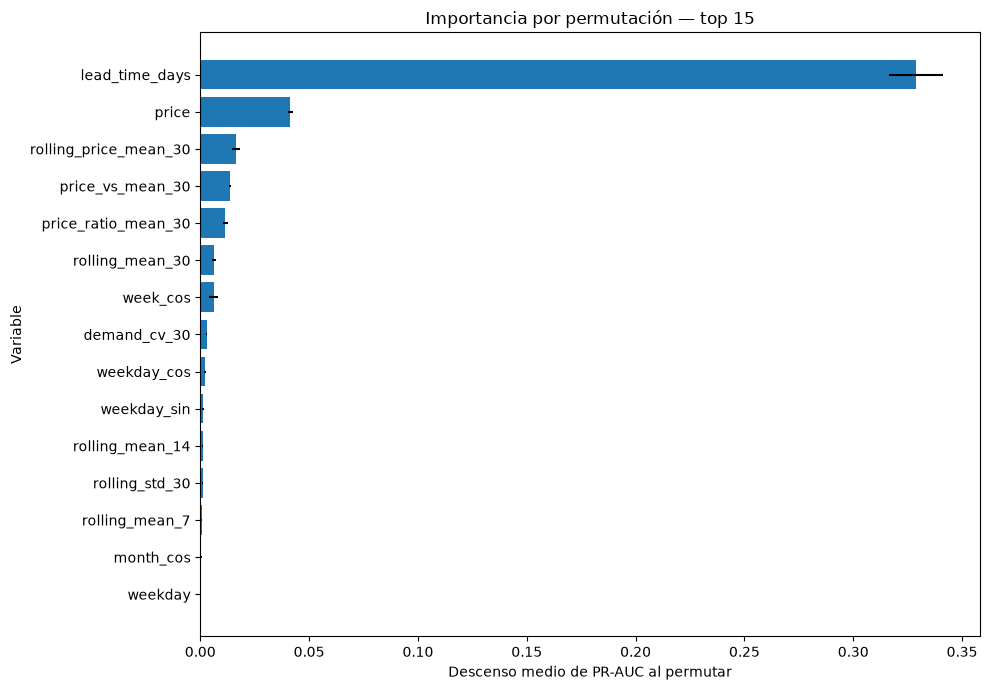

In [13]:
# En esta celda desarrollo el paso explicado justo arriba.
plot_df = permutation_importance_df.head(15).sort_values("importance_mean")

plt.figure(figsize=(10, 7))
plt.barh(plot_df["feature"], plot_df["importance_mean"], xerr=plot_df["importance_std"])
plt.xlabel("Descenso medio de PR-AUC al permutar")
plt.ylabel("Variable")
plt.title("Importancia por permutación — top 15")
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "permutation_feature_importance.png", dpi=160, bbox_inches="tight")
plt.show()

### 7.1 Explicabilidad con SHAP

### ¿Por qué utilizo SHAP?

Utilizo SHAP para entender cómo influye cada variable en las predicciones del modelo.

Esta técnica me permite analizar la importancia global de las variables y también revisar casos concretos.

Podría utilizar únicamente la importancia interna del modelo, pero SHAP aporta una explicación más completa sobre el sentido y la intensidad de cada efecto.


In [14]:
# En esta celda desarrollo el paso explicado justo arriba.
try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False
    print("SHAP no está instalado. Instálalo con: python -m pip install shap")

### ¿Por qué utilizo SHAP?

Utilizo SHAP para entender cómo influye cada variable en las predicciones del modelo.

Esta técnica me permite analizar la importancia global de las variables y también revisar casos concretos.

Podría utilizar únicamente la importancia interna del modelo, pero SHAP aporta una explicación más completa sobre el sentido y la intensidad de cada efecto.


Background dataset has 2000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=2000 when initializing the masker.
 98%|===================| 1966/2000 [00:22<00:00]        

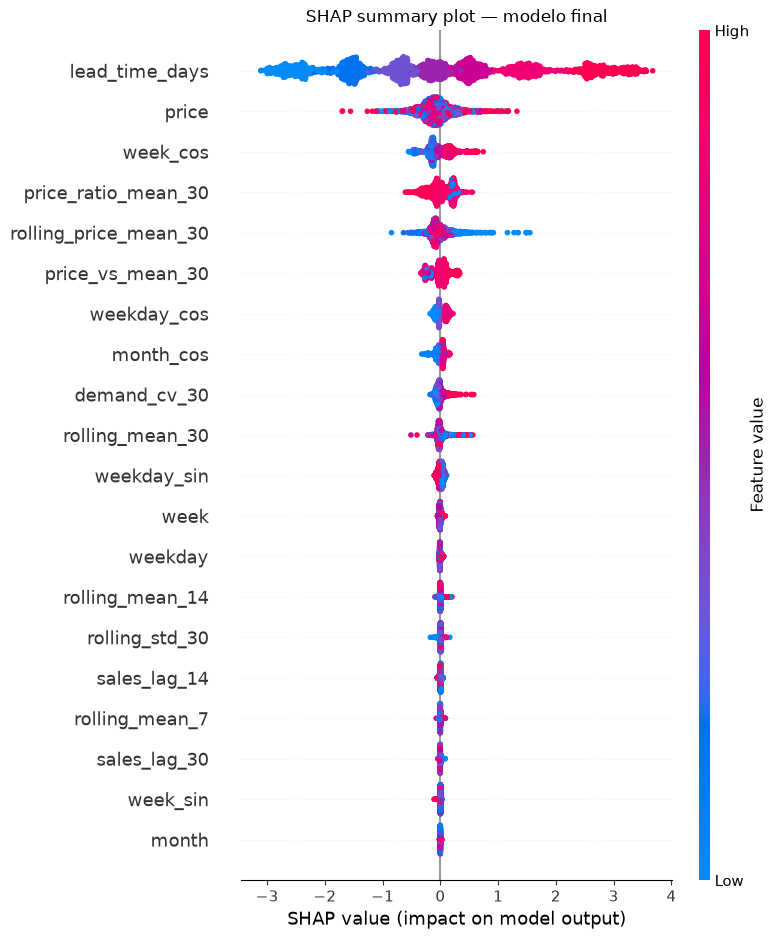

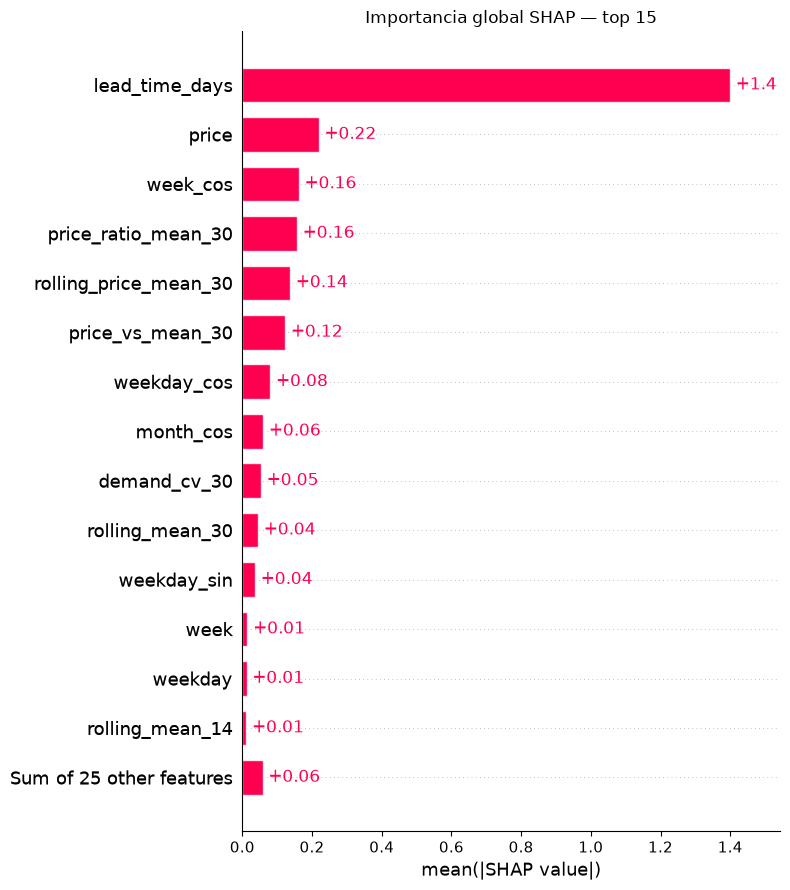

In [15]:
# En esta celda desarrollo el paso explicado justo arriba.
shap_status = {"executed": False, "method": None, "error": None}

if SHAP_AVAILABLE:
    shap_sample_n = min(2000, len(X_test))
    X_shap = X_test.sample(shap_sample_n, random_state=RANDOM_STATE)

    try:
        # Para pipelines, SHAP se aplica sobre la matriz transformada y el estimador final.
        if hasattr(model, "named_steps") and len(model.named_steps) > 1:
            preprocessing_steps = list(model.named_steps.items())[:-1]
            transformed = X_shap.copy()
            for _, step in preprocessing_steps:
                transformed = step.transform(transformed)
            X_shap_for_explainer = transformed
            shap_feature_names = model_features
            shap_estimator = estimator
        else:
            X_shap_for_explainer = X_shap
            shap_feature_names = model_features
            shap_estimator = model

        explainer = shap.Explainer(shap_estimator, X_shap_for_explainer)
        shap_values = explainer(X_shap_for_explainer)

        shap.summary_plot(
            shap_values,
            X_shap_for_explainer,
            feature_names=shap_feature_names,
            show=False,
        )
        plt.title("SHAP summary plot — modelo final")
        plt.tight_layout()
        plt.savefig(OUTPUT_FIGURES_DIR / "shap_summary_plot.png", dpi=160, bbox_inches="tight")
        plt.show()

        shap.plots.bar(shap_values, max_display=15, show=False)
        plt.title("Importancia global SHAP — top 15")
        plt.tight_layout()
        plt.savefig(OUTPUT_FIGURES_DIR / "shap_global_bar.png", dpi=160, bbox_inches="tight")
        plt.show()

        shap_status = {"executed": True, "method": type(explainer).__name__, "error": None}

    except Exception as exc:
        shap_status = {"executed": False, "method": None, "error": str(exc)}
        print("SHAP no pudo ejecutarse con este pipeline/modelo.")
        print("La explicabilidad global queda cubierta mediante importancia nativa y permutación.")
        print("Detalle:", exc)

with open(OUTPUT_REPORTS_DIR / "shap_execution_status.json", "w", encoding="utf-8") as file:
    json.dump(shap_status, file, indent=2, ensure_ascii=False)

## 8. Análisis de errores

Los errores se estudian por tipo:

- **Falso negativo:** riesgo real del target sintético que el modelo no detectó.
- **Falso positivo:** alerta que no coincidió con el target.
- **Verdadero positivo:** riesgo correctamente priorizado.
- **Verdadero negativo:** caso correctamente descartado.

Este análisis es más útil que una métrica agregada porque permite detectar segmentos problemáticos.

### ¿Por qué analizo los errores por grupos?

Un modelo puede funcionar bien en general y peor en determinados productos, tiendas o periodos.

Por eso agrupo los errores cuando dispongo de esas variables. Mi objetivo es detectar si existe algún segmento que necesite más atención.

Antes de crear modelos específicos por grupo, necesito comprobar si realmente aparecen diferencias importantes.


In [16]:
# En esta celda desarrollo el paso explicado justo arriba.
analysis_df = predictions.copy()
analysis_df["y_pred_050"] = y_pred_050
analysis_df["error_type"] = np.select(
    [
        (analysis_df["y_true"] == 1) & (analysis_df["y_pred_050"] == 1),
        (analysis_df["y_true"] == 0) & (analysis_df["y_pred_050"] == 1),
        (analysis_df["y_true"] == 1) & (analysis_df["y_pred_050"] == 0),
        (analysis_df["y_true"] == 0) & (analysis_df["y_pred_050"] == 0),
    ],
    ["TP", "FP", "FN", "TN"],
    default="UNKNOWN",
)

error_summary = (
    analysis_df.groupby("error_type", observed=True)
    .agg(cases=("y_true", "size"), mean_probability=("y_proba", "mean"))
    .reset_index()
)
error_summary["percentage"] = error_summary["cases"] / len(analysis_df)
error_summary.to_csv(OUTPUT_METRICS_DIR / "error_type_summary.csv", index=False)
display(error_summary)

,error_type,cases,mean_probability,percentage
0,FN,106959,0.3532,0.1195
1,FP,77718,0.6498,0.0868
2,TN,339479,0.2193,0.3793
3,TP,370844,0.7986,0.4144


### ¿Por qué analizo los errores por grupos?

Un modelo puede funcionar bien en general y peor en determinados productos, tiendas o periodos.

Por eso agrupo los errores cuando dispongo de esas variables. Mi objetivo es detectar si existe algún segmento que necesite más atención.

Antes de crear modelos específicos por grupo, necesito comprobar si realmente aparecen diferencias importantes.


In [17]:
# En esta celda desarrollo el paso explicado justo arriba.
segment_columns = [col for col in ["store_id", "item_id", "year", "month", "promo", "lead_time_days"] if col in analysis_df.columns]

segment_reports = []
for column in segment_columns:
    report = (
        analysis_df.groupby(column, dropna=False, observed=True)
        .agg(
            cases=("y_true", "size"),
            actual_positive_rate=("y_true", "mean"),
            predicted_positive_rate=("y_pred_050", "mean"),
            mean_probability=("y_proba", "mean"),
        )
        .reset_index()
    )
    report["false_negative_rate"] = (
        analysis_df.assign(is_fn=(analysis_df["error_type"] == "FN").astype(int))
        .groupby(column, dropna=False, observed=True)["is_fn"].mean()
        .reindex(report[column])
        .to_numpy()
    )
    report["false_positive_rate"] = (
        analysis_df.assign(is_fp=(analysis_df["error_type"] == "FP").astype(int))
        .groupby(column, dropna=False, observed=True)["is_fp"].mean()
        .reindex(report[column])
        .to_numpy()
    )
    report["segment"] = column
    report = report.rename(columns={column: "segment_value"})
    segment_reports.append(report)

if segment_reports:
    segment_error_df = pd.concat(segment_reports, ignore_index=True)
    segment_error_df.to_csv(OUTPUT_METRICS_DIR / "segment_error_analysis.csv", index=False)
    display(segment_error_df.sort_values(["segment", "cases"], ascending=[True, False]).head(30))
else:
    segment_error_df = pd.DataFrame()
    print("El archivo de predicciones no contiene columnas segmentables adicionales.")

,segment_value,cases,actual_positive_rate,predicted_positive_rate,mean_probability,false_negative_rate,false_positive_rate,segment
50,item_1,17900,0.6507,0.6055,0.5549,0.1154,0.0701,item_id
51,item_10,17900,0.5324,0.4651,0.5077,0.1531,0.0859,item_id
52,item_11,17900,0.3882,0.3636,0.4161,0.0801,0.0555,item_id
53,item_12,17900,0.5704,0.5626,0.5536,0.1652,0.1574,item_id
54,item_13,17900,0.5742,0.6033,0.5872,0.0961,0.1253,item_id
55,item_14,17900,0.4549,0.4572,0.4860,0.1175,0.1198,item_id
56,item_15,17900,0.6282,0.5108,0.5336,0.1521,0.0347,item_id
57,item_16,17900,0.5556,0.4909,0.4913,0.1416,0.0769,item_id
58,item_17,17900,0.4713,0.4412,0.5151,0.0851,0.0550,item_id
59,item_18,17900,0.3363,0.3517,0.3816,0.0701,0.0855,item_id


### ¿Qué quiero conseguir con este análisis?

En este bloque reviso el comportamiento del modelo desde un punto de vista más práctico.

No me interesa únicamente saber si el modelo acierta, sino entender en qué casos falla, qué variables influyen y cómo podrían utilizarse las predicciones para tomar decisiones.

Una alternativa sería limitarme a mostrar las métricas generales, pero eso no sería suficiente para explicar el valor del modelo ni sus limitaciones.


In [18]:
# En esta celda desarrollo el paso explicado justo arriba.
example_columns = [
    col for col in ["date", "store_id", "item_id", "y_true", "y_pred_050", "y_proba", "error_type"]
    if col in analysis_df.columns
]
error_examples = pd.concat([
    analysis_df[analysis_df["error_type"] == "FN"].sort_values("y_proba").head(10),
    analysis_df[analysis_df["error_type"] == "FP"].sort_values("y_proba", ascending=False).head(10),
    analysis_df[analysis_df["error_type"] == "TP"].sort_values("y_proba", ascending=False).head(10),
], ignore_index=True)

error_examples[example_columns].to_csv(
    OUTPUT_REPORTS_DIR / "representative_prediction_errors.csv", index=False
)
display(error_examples[example_columns].head(30))

,date,store_id,item_id,y_true,y_pred_050,y_proba,error_type
0,2023-08-08,store_32,item_24,1,0,0.0261,FN
1,2023-03-14,store_32,item_24,1,0,0.0292,FN
2,2023-12-12,store_32,item_24,1,0,0.0305,FN
3,2023-01-11,store_32,item_24,1,0,0.0307,FN
4,2023-03-28,store_20,item_21,1,0,0.0337,FN
5,2023-11-22,store_20,item_21,1,0,0.0338,FN
6,2023-03-06,store_20,item_21,1,0,0.0342,FN
7,2023-02-21,store_32,item_24,1,0,0.0342,FN
8,2023-02-06,store_32,item_24,1,0,0.0343,FN
9,2023-10-17,store_20,item_21,1,0,0.0350,FN


## 9. Optimización del umbral de decisión

El umbral 0,50 no es necesariamente el mejor para el negocio. Comparon umbrales entre 0,10 y 0,90.

El umbral técnico se selecciona por F1, pero el umbral operativo se decidirá mediante costes y capacidad de revisión.

### ¿Por qué reviso la matriz de confusión?

La matriz de confusión me permite ver los aciertos y los errores en valores absolutos.

Me fijo especialmente en los falsos negativos, porque representan casos de riesgo que el modelo no detecta, y en los falsos positivos, porque generan revisiones innecesarias.

Las métricas resumen el rendimiento, pero esta matriz ayuda a interpretar mejor qué está ocurriendo.


In [19]:
# En esta celda desarrollo el paso explicado justo arriba.
thresholds = np.round(np.arange(0.10, 0.91, 0.025), 3)
threshold_rows = []

for threshold in thresholds:
    pred = (y_proba >= threshold).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, pred),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "f1_score": f1_score(y_true, pred, zero_division=0),
        "tn": int(tn_t),
        "fp": int(fp_t),
        "fn": int(fn_t),
        "tp": int(tp_t),
        "alerts_generated": int(tp_t + fp_t),
        "alert_rate": float((tp_t + fp_t) / len(y_true)),
        "stockout_capture_rate": float(tp_t / (tp_t + fn_t)) if (tp_t + fn_t) else 0.0,
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(OUTPUT_METRICS_DIR / "threshold_analysis.csv", index=False)

best_f1_row = threshold_df.loc[threshold_df["f1_score"].idxmax()]
display(threshold_df.head())
print("Mejor umbral por F1:", float(best_f1_row["threshold"]))

,threshold,accuracy,precision,recall,f1_score,tn,fp,fn,tp,alerts_generated,alert_rate,stockout_capture_rate
0,0.1000,0.6360,0.5950,0.9965,0.7451,93086,324111,1693,476110,800221,0.8941,0.9965
1,0.1250,0.6566,0.6093,0.9941,0.7556,112661,304536,2813,474990,779526,0.8710,0.9941
2,0.1500,0.6771,0.6246,0.9905,0.7661,132783,284414,4538,473265,757679,0.8466,0.9905
3,0.1750,0.6975,0.6412,0.9838,0.7764,154186,263011,7729,470074,733085,0.8191,0.9838
4,0.2000,0.7155,0.6576,0.9745,0.7853,174803,242394,12203,465600,707994,0.7911,0.9745


Mejor umbral por F1: 0.4


### ¿Qué quiero conseguir con este análisis?

En este bloque reviso el comportamiento del modelo desde un punto de vista más práctico.

No me interesa únicamente saber si el modelo acierta, sino entender en qué casos falla, qué variables influyen y cómo podrían utilizarse las predicciones para tomar decisiones.

Una alternativa sería limitarme a mostrar las métricas generales, pero eso no sería suficiente para explicar el valor del modelo ni sus limitaciones.


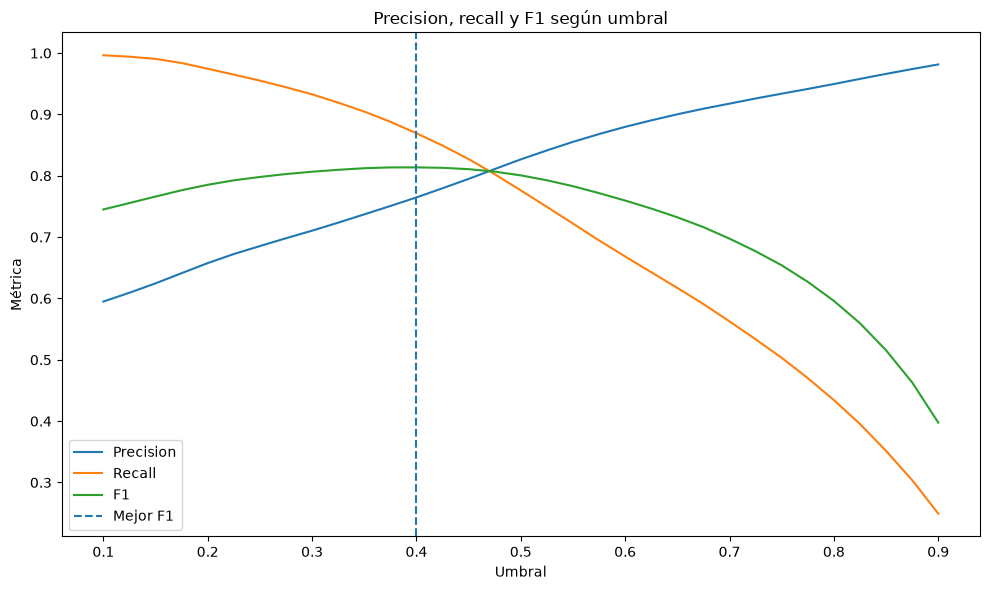

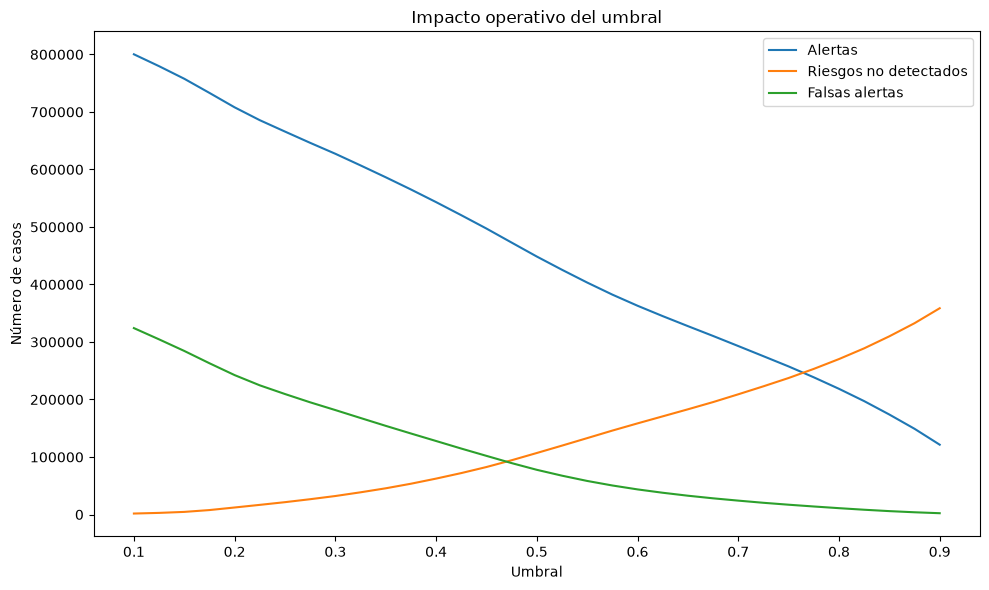

In [20]:
# En esta celda desarrollo el paso explicado justo arriba.
plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1_score"], label="F1")
plt.axvline(float(best_f1_row["threshold"]), linestyle="--", label="Mejor F1")
plt.xlabel("Umbral")
plt.ylabel("Métrica")
plt.title("Precision, recall y F1 según umbral")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "threshold_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(threshold_df["threshold"], threshold_df["alerts_generated"], label="Alertas")
plt.plot(threshold_df["threshold"], threshold_df["fn"], label="Riesgos no detectados")
plt.plot(threshold_df["threshold"], threshold_df["fp"], label="Falsas alertas")
plt.xlabel("Umbral")
plt.ylabel("Número de casos")
plt.title("Impacto operativo del umbral")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "threshold_operational_impact.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. Simulación económica por escenarios

Los valores siguientes son **supuestos editables**, no datos reales:

- `cost_review_alert`: coste de revisar cualquier alerta.
- `loss_per_missed_stockout`: pérdida asociada a un caso positivo no anticipado.
- `avoidable_loss_rate`: fracción de la pérdida que podría evitarse al actuar sobre una alerta correcta.

El coste con modelo incluye la revisión de todas las alertas y la pérdida residual de los falsos negativos.

### ¿Por qué pruebo distintos umbrales?

El valor 0,50 es una referencia habitual, pero no tiene por qué ser el más útil para este problema.

Un umbral más bajo detecta más casos, aunque puede generar más falsas alertas. Un umbral más alto reduce las alertas, pero puede dejar más riesgos sin detectar.

Por eso comparo varios valores antes de decidir cuál podría utilizarse.


In [21]:
# En esta celda desarrollo el paso explicado justo arriba.
business_scenarios = pd.DataFrame([
    {
        "scenario": "Conservador",
        "cost_review_alert": 15.0,
        "loss_per_missed_stockout": 50.0,
        "avoidable_loss_rate": 0.30,
    },
    {
        "scenario": "Base",
        "cost_review_alert": 10.0,
        "loss_per_missed_stockout": 100.0,
        "avoidable_loss_rate": 0.60,
    },
    {
        "scenario": "Optimista",
        "cost_review_alert": 8.0,
        "loss_per_missed_stockout": 200.0,
        "avoidable_loss_rate": 0.80,
    },
])

business_rows = []
total_positives = int(np.sum(y_true))

for _, scenario in business_scenarios.iterrows():
    baseline_loss = total_positives * scenario["loss_per_missed_stockout"]

    for _, row in threshold_df.iterrows():
        review_cost = row["alerts_generated"] * scenario["cost_review_alert"]
        residual_loss_detected = (
            row["tp"]
            * scenario["loss_per_missed_stockout"]
            * (1 - scenario["avoidable_loss_rate"])
        )
        missed_loss = row["fn"] * scenario["loss_per_missed_stockout"]
        cost_with_model = review_cost + residual_loss_detected + missed_loss
        gross_avoided_loss = (
            row["tp"]
            * scenario["loss_per_missed_stockout"]
            * scenario["avoidable_loss_rate"]
        )
        net_benefit = baseline_loss - cost_with_model
        roi = net_benefit / review_cost if review_cost > 0 else np.nan

        business_rows.append({
            **scenario.to_dict(),
            "threshold": row["threshold"],
            "tp": int(row["tp"]),
            "fp": int(row["fp"]),
            "fn": int(row["fn"]),
            "alerts_generated": int(row["alerts_generated"]),
            "baseline_loss": baseline_loss,
            "gross_avoided_loss": gross_avoided_loss,
            "review_cost": review_cost,
            "cost_with_model": cost_with_model,
            "net_benefit": net_benefit,
            "roi": roi,
        })

business_df = pd.DataFrame(business_rows)
business_df.to_csv(OUTPUT_METRICS_DIR / "business_scenario_analysis.csv", index=False)

best_business_thresholds = (
    business_df.sort_values(["scenario", "net_benefit"], ascending=[True, False])
    .groupby("scenario", as_index=False)
    .head(1)
    .reset_index(drop=True)
)
best_business_thresholds.to_csv(
    OUTPUT_METRICS_DIR / "best_business_thresholds.csv", index=False
)
display(best_business_thresholds)

,scenario,cost_review_alert,loss_per_missed_stockout,avoidable_loss_rate,threshold,tp,fp,fn,alerts_generated,baseline_loss,gross_avoided_loss,review_cost,cost_with_model,net_benefit,roi
0,Base,10.0000,100.0000,0.6000,0.1750,470074,263011,7729,733085,"47,780,300.0000","28,204,440.0000","7,330,850.0000","26,906,710.0000","20,873,590.0000",2.8474
1,Conservador,15.0000,50.0000,0.3000,0.9000,119129,2252,358674,121381,"23,890,150.0000","1,786,935.0000","1,820,715.0000","23,923,930.0000","-33,780.0000",-0.0186
2,Optimista,8.0000,200.0000,0.8000,0.1000,476110,324111,1693,800221,"95,560,600.0000","76,177,600.0000","6,401,768.0000","25,784,768.0000","69,775,832.0000",10.8995


### ¿Por qué pruebo distintos umbrales?

El valor 0,50 es una referencia habitual, pero no tiene por qué ser el más útil para este problema.

Un umbral más bajo detecta más casos, aunque puede generar más falsas alertas. Un umbral más alto reduce las alertas, pero puede dejar más riesgos sin detectar.

Por eso comparo varios valores antes de decidir cuál podría utilizarse.


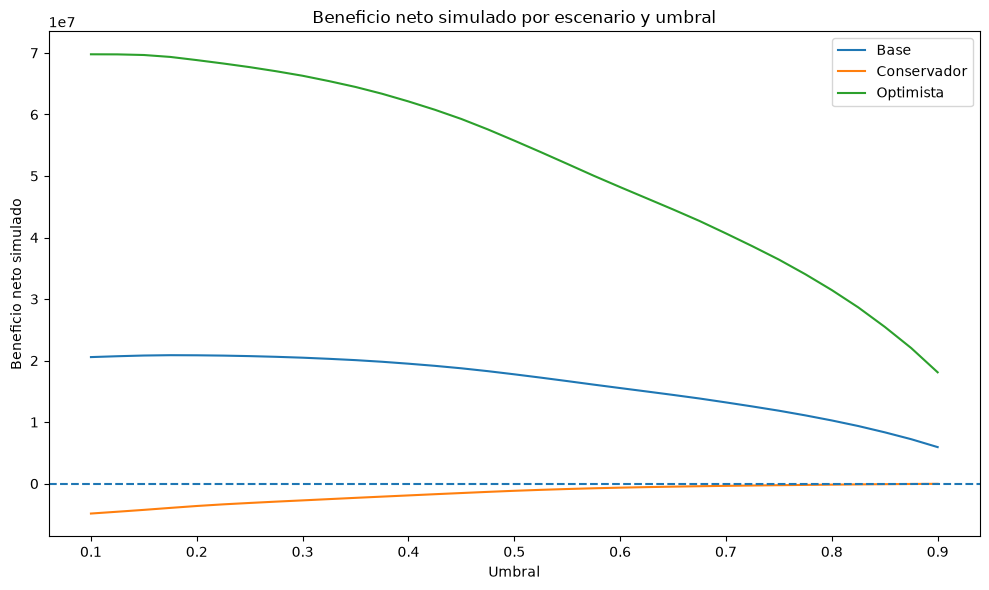

In [22]:
# En esta celda desarrollo el paso explicado justo arriba.
plt.figure(figsize=(10, 6))
for scenario, group in business_df.groupby("scenario", observed=True):
    plt.plot(group["threshold"], group["net_benefit"], label=scenario)
plt.axhline(0, linestyle="--")
plt.xlabel("Umbral")
plt.ylabel("Beneficio neto simulado")
plt.title("Beneficio neto simulado por escenario y umbral")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "business_net_benefit_by_threshold.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Priorización por capacidad operativa

En una operación real puede ser más útil revisar el top N % de probabilidades que fijar un único umbral.

Calculo:

- cobertura de casos positivos;
- precisión dentro del grupo revisado;
- lift frente a seleccionar casos aleatoriamente.

### ¿Por qué analizo los registros con mayor riesgo?

En una situación real no siempre se pueden revisar todas las predicciones.

Por eso ordeno los casos por probabilidad y analizo qué ocurre si solo se revisa el grupo con mayor riesgo.

Este enfoque permite comprobar si el modelo es útil como herramienta de priorización cuando los recursos son limitados.


In [23]:
# En esta celda desarrollo el paso explicado justo arriba.
ranked = analysis_df.sort_values("y_proba", ascending=False).reset_index(drop=True)
total_positive = int(ranked["y_true"].sum())
base_positive_rate = float(ranked["y_true"].mean())

top_percentages = [0.01, 0.05, 0.10, 0.20, 0.30, 0.50]
priority_rows = []

for pct in top_percentages:
    n_reviewed = max(1, int(np.ceil(len(ranked) * pct)))
    selected = ranked.head(n_reviewed)
    positives_found = int(selected["y_true"].sum())
    precision_at_k = positives_found / n_reviewed
    recall_at_k = positives_found / total_positive if total_positive else 0.0
    lift = precision_at_k / base_positive_rate if base_positive_rate else np.nan

    priority_rows.append({
        "top_percentage": pct,
        "reviewed_cases": n_reviewed,
        "positives_found": positives_found,
        "precision_at_k": precision_at_k,
        "recall_at_k": recall_at_k,
        "lift_vs_random": lift,
    })

prioritization_df = pd.DataFrame(priority_rows)
prioritization_df.to_csv(OUTPUT_METRICS_DIR / "risk_prioritization.csv", index=False)
display(prioritization_df)

,top_percentage,reviewed_cases,positives_found,precision_at_k,recall_at_k,lift_vs_random
0,0.0100,8950,8943,0.9992,0.0187,1.8717
1,0.0500,44750,44451,0.9933,0.0930,1.8606
2,0.1000,89500,88296,0.9865,0.1848,1.8480
3,0.2000,179000,172628,0.9644,0.3613,1.8065
4,0.3000,268500,249459,0.9291,0.5221,1.7403
5,0.5000,447500,370261,0.8274,0.7749,1.5498


### ¿Por qué analizo los registros con mayor riesgo?

En una situación real no siempre se pueden revisar todas las predicciones.

Por eso ordeno los casos por probabilidad y analizo qué ocurre si solo se revisa el grupo con mayor riesgo.

Este enfoque permite comprobar si el modelo es útil como herramienta de priorización cuando los recursos son limitados.


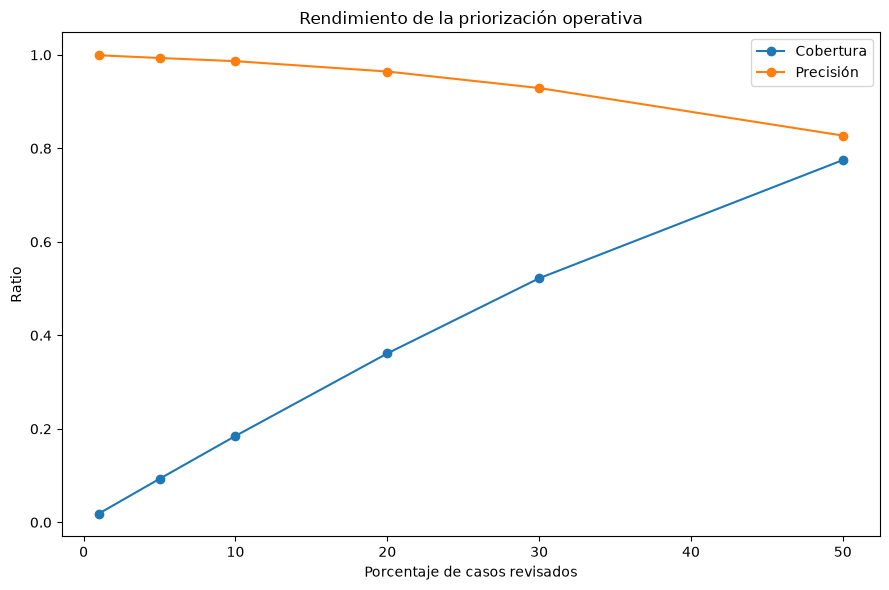

In [24]:
# En esta celda desarrollo el paso explicado justo arriba.
plt.figure(figsize=(9, 6))
plt.plot(prioritization_df["top_percentage"] * 100, prioritization_df["recall_at_k"], marker="o", label="Cobertura")
plt.plot(prioritization_df["top_percentage"] * 100, prioritization_df["precision_at_k"], marker="o", label="Precisión")
plt.xlabel("Porcentaje de casos revisados")
plt.ylabel("Ratio")
plt.title("Rendimiento de la priorización operativa")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_FIGURES_DIR / "risk_prioritization.png", dpi=160, bbox_inches="tight")
plt.show()

## 12. Propuesta conceptual de producción

### Tipo de ejecución

El caso de uso se desplegaría inicialmente como un **proceso batch diario**, no como predicción en tiempo real:

```text
WMS / ERP / ventas
        ↓
Extracción diaria
        ↓
Validación y transformación
        ↓
Generación de features históricas
        ↓
Modelo de riesgo
        ↓
Ranking tienda-producto
        ↓
Dashboard / tabla de alertas
        ↓
Revisión del planificador
```

### Componentes propuestos

- Ingesta desde WMS, ERP o data warehouse.
- Pipeline versionado de transformación.
- Registro de experimentos y modelos.
- Ejecución programada.
- Tabla de probabilidades y motivos principales.
- Visualización en Cognos, Power BI o Streamlit.
- Revisión humana antes de modificar pedidos o reposiciones.

### Reentrenamiento

- Frecuencia inicial: mensual.
- Reentrenamiento anticipado cuando se supere un umbral de degradación o drift.
- Comparación obligatoria contra el modelo activo antes de promover una versión nueva.

### Monitorización

Se monitorizarían:

- PR-AUC, recall, precision y F1 cuando llegue la etiqueta real.
- Recall y precision en el top de riesgo.
- Volumen y tasa de alertas.
- Falsos negativos y falsas alertas.
- Distribución de probabilidades.
- Missing values y rangos inválidos.
- Drift de features y de predicciones.
- Tiempo de inferencia y fallos del proceso.

### Versionado y actualización

- Código y configuración en Git.
- Artefactos del modelo versionados.
- Diccionario de features y esquema de entrada.
- Registro del periodo de entrenamiento.
- Despliegue progresivo y posibilidad de rollback.

## 13. Plan de monitorización estructurado

### ¿Por qué analizo los registros con mayor riesgo?

En una situación real no siempre se pueden revisar todas las predicciones.

Por eso ordeno los casos por probabilidad y analizo qué ocurre si solo se revisa el grupo con mayor riesgo.

Este enfoque permite comprobar si el modelo es útil como herramienta de priorización cuando los recursos son limitados.


In [25]:
# En esta celda desarrollo el paso explicado justo arriba.
monitoring_plan = pd.DataFrame([
    ["Calidad de datos", "Nulos, duplicados, rangos, frecuencia temporal", "Cada ejecución", "Detener pipeline o generar alerta"],
    ["Drift de variables", "PSI, KS o divergencia por feature", "Semanal", "Investigar y valorar reentrenamiento"],
    ["Drift de predicción", "Distribución de probabilidades y tasa de alertas", "Diario", "Revisar cambios bruscos"],
    ["Rendimiento", "PR-AUC, recall, precision, F1", "Cuando madure la etiqueta", "Comparar con umbral operativo"],
    ["Negocio", "Cobertura top N, falsas alertas, incidencias evitadas", "Semanal/Mensual", "Ajustar umbral y capacidad"],
    ["Operación", "Tiempo de ejecución y fallos", "Cada ejecución", "Reintentar o escalar incidencia"],
], columns=["area", "indicator", "frequency", "action"])

monitoring_plan.to_csv(OUTPUT_REPORTS_DIR / "production_monitoring_plan.csv", index=False)
display(monitoring_plan)

,area,indicator,frequency,action
0,Calidad de datos,"Nulos, duplicados, rangos, frecuencia temporal",Cada ejecución,Detener pipeline o generar alerta
1,Drift de variables,"PSI, KS o divergencia por feature",Semanal,Investigar y valorar reentrenamiento
2,Drift de predicción,Distribución de probabilidades y tasa de alertas,Diario,Revisar cambios bruscos
3,Rendimiento,"PR-AUC, recall, precision, F1",Cuando madure la etiqueta,Comparar con umbral operativo
4,Negocio,"Cobertura top N, falsas alertas, incidencias e...",Semanal/Mensual,Ajustar umbral y capacidad
5,Operación,Tiempo de ejecución y fallos,Cada ejecución,Reintentar o escalar incidencia


## 14. Resumen ejecutivo exportable

### ¿Por qué calculo la importancia por permutación?

Cambio de forma controlada los valores de cada variable y observo cuánto empeora el rendimiento del modelo.

Si el resultado empeora mucho, considero que esa variable aporta información importante.

Uso esta técnica como complemento porque funciona con distintos tipos de modelos y no depende únicamente de la importancia interna del algoritmo.


In [26]:
# En esta celda desarrollo el paso explicado justo arriba.
top_features = permutation_importance_df.head(5)["feature"].tolist()
base_business = best_business_thresholds[
    best_business_thresholds["scenario"] == "Base"
]
base_business = base_business.iloc[0] if not base_business.empty else None

summary_lines = [
    "# Resumen ejecutivo — explicabilidad y negocio",
    "",
    "## Rendimiento técnico",
    f"- ROC-AUC: {final_metrics['roc_auc']:.4f}",
    f"- PR-AUC: {final_metrics['pr_auc']:.4f}",
    f"- Precision con umbral 0,50: {final_metrics['precision']:.4f}",
    f"- Recall con umbral 0,50: {final_metrics['recall']:.4f}",
    f"- F1 con umbral 0,50: {final_metrics['f1_score']:.4f}",
    "",
    "## Operación con umbral 0,50",
    f"- Alertas: {final_metrics['alerts_generated']}",
    f"- Riesgos detectados: {final_metrics['tp']}",
    f"- Riesgos no detectados: {final_metrics['fn']}",
    f"- Falsas alertas: {final_metrics['fp']}",
    "",
    "## Variables más relevantes por permutación",
]
summary_lines.extend([f"- {feature}" for feature in top_features])

summary_lines.extend([
    "",
    "## Selección de umbral",
    f"- Mejor umbral técnico por F1: {float(best_f1_row['threshold']):.3f}",
])

if base_business is not None:
    summary_lines.extend([
        f"- Mejor umbral simulado en escenario base: {float(base_business['threshold']):.3f}",
        f"- Beneficio neto simulado en escenario base: {float(base_business['net_benefit']):,.2f}",
        f"- ROI simulado en escenario base: {float(base_business['roi']):.4f}",
    ])

summary_lines.extend([
    "",
    "## Limitación",
    "- El target y los costes son simulados. El proyecto demuestra metodología y valor potencial, no impacto económico real.",
    "- Antes de producción se necesitarían datos reales de inventario, pedidos, reposiciones, ventas perdidas y lead time.",
])

summary_path = OUTPUT_REPORTS_DIR / "explainability_business_summary.md"
summary_path.write_text("\n".join(summary_lines), encoding="utf-8")
print(summary_path.read_text(encoding="utf-8"))

# Resumen ejecutivo — explicabilidad y negocio

## Rendimiento técnico
- ROC-AUC: 0.8843
- PR-AUC: 0.8990
- Precision con umbral 0,50: 0.8267
- Recall con umbral 0,50: 0.7761
- F1 con umbral 0,50: 0.8006

## Operación con umbral 0,50
- Alertas: 448562
- Riesgos detectados: 370844
- Riesgos no detectados: 106959
- Falsas alertas: 77718

## Variables más relevantes por permutación
- lead_time_days
- price
- rolling_price_mean_30
- price_vs_mean_30
- price_ratio_mean_30

## Selección de umbral
- Mejor umbral técnico por F1: 0.400
- Mejor umbral simulado en escenario base: 0.175
- Beneficio neto simulado en escenario base: 20,873,590.00
- ROI simulado en escenario base: 2.8474

## Limitación
- El target y los costes son simulados. El proyecto demuestra metodología y valor potencial, no impacto económico real.
- Antes de producción se necesitarían datos reales de inventario, pedidos, reposiciones, ventas perdidas y lead time.


## 15. Conclusiones

El modelo debe utilizarse como **sistema de apoyo y priorización**, no como automatización autónoma de reposición.


1. El modelo puede ordenar casos por riesgo y concentrar la revisión operativa.
2. El umbral 0,50 es una referencia técnica, no una decisión empresarial óptima.
3. La importancia de variables y SHAP ayudan a comprobar que el modelo utiliza señales coherentes, pero no prueban causalidad.
4. Los falsos negativos son el error operativo más sensible, mientras que los falsos positivos consumen capacidad de revisión.
5. El valor económico depende de costes reales que no existen en el dataset; por eso se presentan escenarios editables.
6. El principal límite es que la rotura de stock no está observada directamente.
7. Una versión productiva exigiría inventario real, pedidos pendientes, recepciones, lead time real y ventas no servidas.